In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("processed")

paths = {
    "val": PROCESSED_DIR / "processed_minimal_val_d0_z0.npz",
    "test_background": PROCESSED_DIR / "processed_minimal_test_background_d0_z0.npz",
    "test_signal": PROCESSED_DIR / "processed_minimal_test_signal_d0_z0.npz",
}

In [2]:
data_val = np.load(paths["val"], allow_pickle=True)
data_bg = np.load(paths["test_background"], allow_pickle=True)
data_sig = np.load(paths["test_signal"], allow_pickle=True)

print("Loaded datasets.")

Loaded datasets.


In [3]:
def describe_dataset(name, data):
    print("\n" + "=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    print("Keys:")
    for k in data.keys():
        print(" -", k)

    X = data["X_tracks"]
    mask = data["track_mask"]
    feature_names = list(data["track_feature_names"])

    print("\nShapes:")
    print("X_tracks:", X.shape)
    print("track_mask:", mask.shape)

    print("\nFeatures:")
    print(feature_names)

    print("\nDtypes:")
    print("X_tracks dtype:", X.dtype)
    print("track_mask dtype:", mask.dtype)

    print("\nChecks:")
    print("finite:", np.isfinite(X).all())
    print("invalid tracks zero:", np.allclose(X[~mask], 0.0))

    valid_counts = mask.sum(axis=1)
    print("\nValid tracks per jet:")
    print("min:", valid_counts.min())
    print("max:", valid_counts.max())
    print("mean:", valid_counts.mean())
    print("median:", np.median(valid_counts))

    valid_values = X[mask]
    print("\nFeature stats on valid tracks:")
    for i, feat in enumerate(feature_names):
        vals = valid_values[:, i]
        print(
            f"{feat:20s} "
            f"mean={vals.mean(): .4f} "
            f"std={vals.std(): .4f} "
            f"min={vals.min(): .4f} "
            f"max={vals.max(): .4f}"
        )

    if "y" in data:
        y = data["y"]
        print("\nLabels y:")
        print(np.unique(y, return_counts=True))


describe_dataset("val", data_val)
describe_dataset("test_background", data_bg)
describe_dataset("test_signal", data_sig)


DATASET: val
Keys:
 - X_tracks
 - track_mask
 - track_feature_names
 - y
 - meta_isDisplaced
 - meta_flavour_label

Shapes:
X_tracks: (50000, 200, 2)
track_mask: (50000, 200)

Features:
['d0', 'z0SinTheta']

Dtypes:
X_tracks dtype: float32
track_mask dtype: bool

Checks:
finite: True
invalid tracks zero: True

Valid tracks per jet:
min: 3
max: 200
mean: 64.78318
median: 59.0

Feature stats on valid tracks:
d0                   mean= 0.0004 std= 1.0034 min=-5.7070 max= 5.7239
z0SinTheta           mean=-0.0005 std= 1.0012 min=-6.0689 max= 6.0656

Labels y:
(array([0]), array([50000]))

DATASET: test_background
Keys:
 - X_tracks
 - track_mask
 - track_feature_names
 - y
 - meta_isDisplaced
 - meta_flavour_label
 - meta_mcEventWeight
 - meta_eventNumber

Shapes:
X_tracks: (50000, 200, 2)
track_mask: (50000, 200)

Features:
['d0', 'z0SinTheta']

Dtypes:
X_tracks dtype: float32
track_mask dtype: bool

Checks:
finite: True
invalid tracks zero: True

Valid tracks per jet:
min: 2
max: 200
mean

In [4]:
X_train = data_val["X_tracks"]
mask_train = data_val["track_mask"]

X_bg = data_bg["X_tracks"]
mask_bg = data_bg["track_mask"]

X_sig = data_sig["X_tracks"]
mask_sig = data_sig["track_mask"]

feature_names = list(data_val["track_feature_names"])

print("Train:", X_train.shape)
print("Background test:", X_bg.shape)
print("Signal test:", X_sig.shape)
print("Features:", feature_names)

Train: (50000, 200, 2)
Background test: (50000, 200, 2)
Signal test: (50000, 200, 2)
Features: ['d0', 'z0SinTheta']


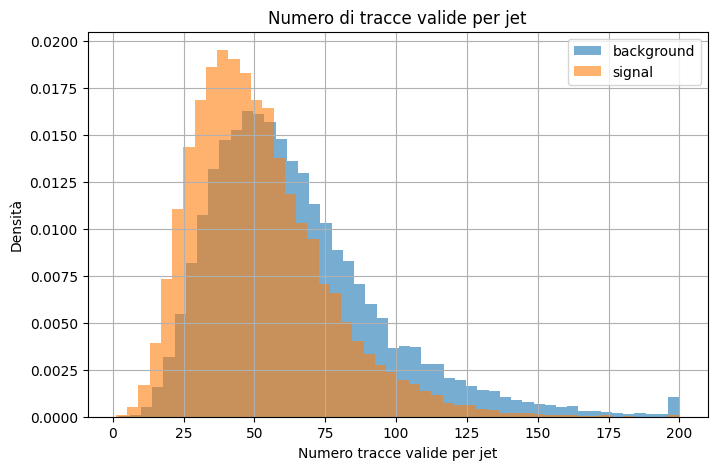

In [5]:
#mh non sono così separate, farà cacare
plt.figure(figsize=(8, 5))

plt.hist(mask_bg.sum(axis=1), bins=50, alpha=0.6, density=True, label="background")
plt.hist(mask_sig.sum(axis=1), bins=50, alpha=0.6, density=True, label="signal")

plt.xlabel("Numero tracce valide per jet")
plt.ylabel("Densità")
plt.title("Numero di tracce valide per jet")
plt.legend()
plt.grid(True)
plt.show()

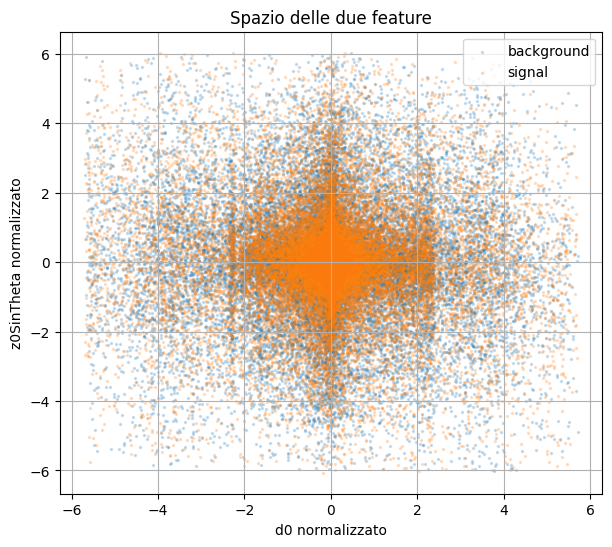

In [6]:
#mh male male
def sample_valid_points(X, mask, max_points=100_000):
    vals = X[mask]
    if len(vals) > max_points:
        idx = np.random.choice(len(vals), size=max_points, replace=False)
        vals = vals[idx]
    return vals

bg_points = sample_valid_points(X_bg, mask_bg)
sig_points = sample_valid_points(X_sig, mask_sig)

plt.figure(figsize=(7, 6))
plt.scatter(bg_points[:, 0], bg_points[:, 1], s=2, alpha=0.2, label="background")
plt.scatter(sig_points[:, 0], sig_points[:, 1], s=2, alpha=0.2, label="signal")
plt.xlabel("d0 normalizzato")
plt.ylabel("z0SinTheta normalizzato")
plt.title("Spazio delle due feature")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class TrackDataset(Dataset):
    def __init__(self, X, mask):
        self.X = torch.from_numpy(X).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx]

In [9]:
class SimpleTrackAutoencoder(nn.Module):
    def __init__(self, n_tracks=200, n_features=2, latent_dim=16):
        super().__init__()

        self.n_tracks = n_tracks
        self.n_features = n_features
        input_dim = n_tracks * n_features

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.reshape(batch_size, self.n_tracks, self.n_features)
        return out

In [10]:
def masked_mse_loss(reco, x, mask):
    mask = mask.unsqueeze(-1)  # (B, 200, 1)
    diff2 = (reco - x) ** 2
    diff2 = diff2 * mask

    denom = mask.sum() * x.shape[-1]
    denom = torch.clamp(denom, min=1)

    return diff2.sum() / denom

In [11]:
train_dataset = TrackDataset(X_train, mask_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

model = SimpleTrackAutoencoder(
    n_tracks=200,
    n_features=2,
    latent_dim=16,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print("Training jets:", len(train_dataset))

SimpleTrackAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=400, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=400, bias=True)
  )
)
Training jets: 50000


In [36]:
n_epochs = 10
loss_history = []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0

    for X_batch, mask_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        reco = model(X_batch)
        loss = masked_mse_loss(reco, X_batch, mask_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]

    avg_loss = total_loss / len(train_dataset)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1:02d}/{n_epochs} - loss = {avg_loss:.6f}")

Epoch 01/10 - loss = 0.770716
Epoch 02/10 - loss = 0.771059
Epoch 03/10 - loss = 0.771360
Epoch 04/10 - loss = 0.771078
Epoch 05/10 - loss = 0.771307
Epoch 06/10 - loss = 0.771238
Epoch 07/10 - loss = 0.770917
Epoch 08/10 - loss = 0.770721
Epoch 09/10 - loss = 0.770724
Epoch 10/10 - loss = 0.771068


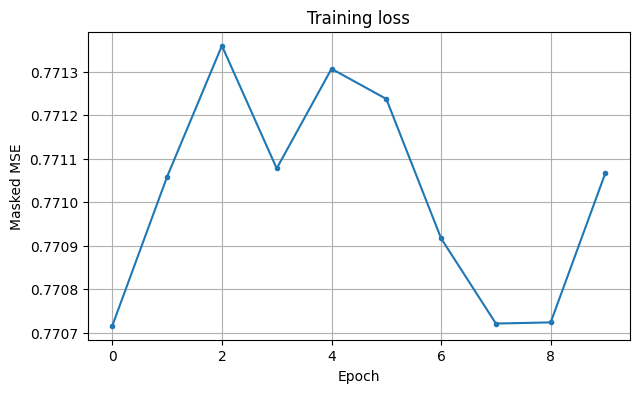

In [37]:
#not bad RIFARE CON 1000 EPOCHE VEDIAMO COME ESCE
plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker=".")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE")
plt.title("Training loss")
plt.grid(True)
plt.show()

In [38]:
def compute_anomaly_scores(model, X, mask, batch_size=2048):
    dataset = TrackDataset(X, mask)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    scores = []

    with torch.no_grad():
        for X_batch, mask_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)

            reco = model(X_batch)

            diff2 = (reco - X_batch) ** 2
            diff2 = diff2 * mask_batch.unsqueeze(-1)

            per_jet_error = diff2.sum(dim=(1, 2))
            per_jet_denom = mask_batch.sum(dim=1) * X_batch.shape[-1]
            per_jet_denom = torch.clamp(per_jet_denom, min=1)

            score = per_jet_error / per_jet_denom
            scores.append(score.cpu().numpy())

    return np.concatenate(scores)

In [39]:
scores_bg = compute_anomaly_scores(model, X_bg, mask_bg)
scores_sig = compute_anomaly_scores(model, X_sig, mask_sig)

print("scores_bg:", scores_bg.shape)
print("scores_sig:", scores_sig.shape)

print("mean background score:", scores_bg.mean())
print("mean signal score:", scores_sig.mean())
print("median background score:", np.median(scores_bg))
print("median signal score:", np.median(scores_sig))

scores_bg: (50000,)
scores_sig: (50000,)
mean background score: 0.7004732
mean signal score: 0.6280519
median background score: 0.52888685
median signal score: 0.50474167


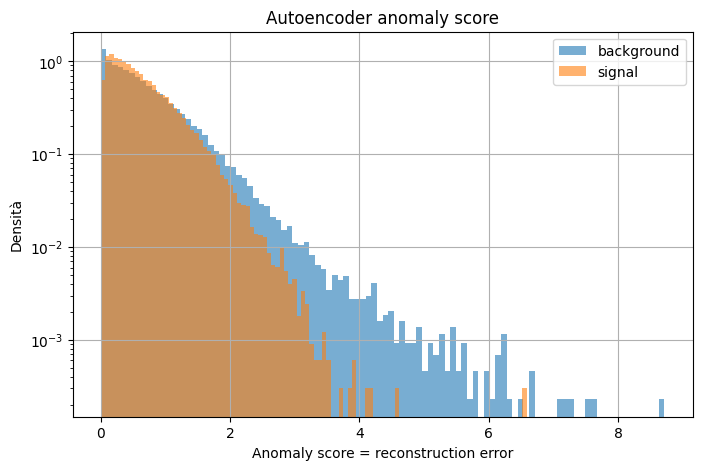

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(scores_bg, bins=100, density=True, alpha=0.6, label="background")
plt.hist(scores_sig, bins=100, density=True, alpha=0.6, label="signal")

plt.yscale("log")
plt.xlabel("Anomaly score = reconstruction error")
plt.ylabel("Densità")
plt.title("Autoencoder anomaly score")
plt.legend()
plt.grid(True)
plt.show()

AUC: 0.49120811940000003


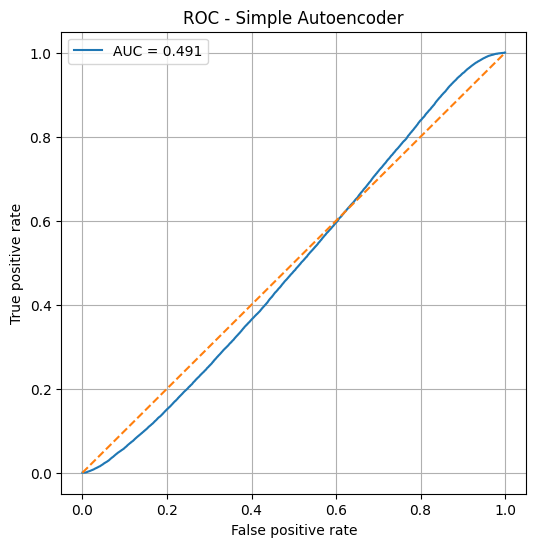

In [41]:
#NO
from sklearn.metrics import roc_auc_score, roc_curve

y_true = np.concatenate([
    np.zeros_like(scores_bg),
    np.ones_like(scores_sig),
])

y_score = np.concatenate([
    scores_bg,
    scores_sig,
])

auc = roc_auc_score(y_true, y_score)
print("AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC - Simple Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

Non cambia praticamente nulla, bisogna o usare qualcos'altro (proprio una rete diversa) o usare altre variabili (procederò così)